# Homework 1 — Series mean vs building embedding

On the single Oct–Dec split the project first used, the two building-aware models almost tie: mlp_4out_emb 1.111,
mlp_4out_mean 1.122. The mean model is much simpler: one extra input instead of a learned 16-number vector per
building.

**Question:** is the mean model not worse than the embedding model over all four seasons?

**Rule, fixed before running:** keep the mean model if its fold-average clean RMSLE is at most 0.01 above the
embedding model's, and it isn't more than 0.01 worse on most folds. Clean rows are the comparison score, all rows
are shown alongside ([season_validation.ipynb](season_validation.ipynb)).

Folds: 2016 in four 3-month blocks, each trained on the other nine months.

In [1]:
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, "..")  # the ashrae package lives in the homework folder
from ashrae.config import FOLDS, METERS
from ashrae.data import read_processed, split
from ashrae.features import add_series_mean, build_features
from ashrae.metrics import rmsle, rmsle_by_meter
from ashrae.modeling import MeterMLP, make_loaders, predict
from ashrae.tracking import Experiment

EPOCHS = 10
N_TRAIN, N_VAL = 2_000_000, 500_000  # rows sampled per fold
experiment = Experiment("ashrae-mean-vs-emb")

2026/09/27 13:26:10 INFO mlflow.tracking.fluent: Experiment with name 'ashrae-mean-vs-emb' does not exist. Creating a new experiment.


MLflow: sqlite:////Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/Homeworks/Homework 1/mlflow.db, experiment 'ashrae-mean-vs-emb', session 2026-09-27 13:26:10


## Data and features

Same rows and features as [season_validation.ipynb](season_validation.ipynb). The series mean is built once per fold
from its training rows; the embedding model gets the same features without that column.

In [2]:
df = read_processed()
n_buildings = int(df.building_id.max()) + 1


def fold_data(val_months):
    train_df, val_df = split(df, val_months, N_TRAIN, N_VAL)
    year_median = train_df.year_built.median()
    X_train = add_series_mean(build_features(train_df, year_median), train_df, train_df)
    X_val = add_series_mean(build_features(val_df, year_median), val_df, train_df)
    no_mean = lambda X: X.drop(columns="series_mean")
    return {
        "mean": make_loaders(train_df, val_df, X_train, X_val)[:2],
        "emb": make_loaders(train_df, val_df, no_mean(X_train), no_mean(X_val))[:2],
        "anomaly": val_df.anomaly.to_numpy(),
        "meter": val_df.meter.to_numpy(),
    }


folds = {name: fold_data(months) for name, months in FOLDS.items()}
n_features = folds["Jan–Mar"]["emb"][0].dataset.x.shape[1]
del df

## Models

Both are mlp_4out ([mlp.ipynb](../models/mlp.ipynb)): 2 hidden layers of 64 (BatchNorm, ReLU), one output per meter
type, Adam, 10 epochs, same seed. They differ only in how they know the building:

- **mean:** the series mean as one extra input;
- **emb:** a learned 16-number vector per building (an embedding), shared by all its meters.

Code: `MeterMLP` in [ashrae/modeling.py](../ashrae/modeling.py).

In [3]:
make_net = {"mean": lambda: MeterMLP(n_features + 1), "emb": lambda: MeterMLP(n_features, n_buildings)}
for name, make in make_net.items():
    print(f"{name:5s} {sum(p.numel() for p in make().parameters()):,} parameters")

mean  6,916 parameters
emb   31,060 parameters


## Training

8 runs (4 folds × 2 models). Validation is predicted once and scored on all and clean rows, overall and per meter.
Everything goes to MLflow, tagged with fold and model.

In [4]:
results, by_meter = [], []
for fold, data in folds.items():
    anomaly, meter = data["anomaly"], data["meter"]
    for model_name in make_net:
        train_loader, val_loader = data[model_name]
        model, run_id = experiment.fit(make_net[model_name], train_loader, run_name=f"{model_name} | {fold}",
                                       epochs=EPOCHS, tags={"fold": fold, "model": model_name})
        pred, y = predict(model, val_loader), val_loader.dataset.y.numpy()
        scores = {"train": experiment.history(run_id, "train_rmsle")[-1],
                  "val_all": rmsle(y, pred), "val_clean": rmsle(y[~anomaly], pred[~anomaly])}
        meters = rmsle_by_meter(y[~anomaly], pred[~anomaly], meter[~anomaly], prefix="clean")
        experiment.log_metrics(run_id, {**{f"rmsle_{k}": v for k, v in scores.items()}, **meters})
        results.append({"fold": fold, "model": model_name, **scores})
        by_meter += [{"fold": fold, "model": model_name, "meter": name, "val_clean": meters[f"clean_{name}"]}
                     for name in METERS.values()]
        print(f"{fold} {model_name:4s}: " + ", ".join(f"{k} {v:.3f}" for k, v in scores.items()))

results, by_meter = pd.DataFrame(results), pd.DataFrame(by_meter)

/Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


Jan–Mar mean: train 0.889, val_all 1.459, val_clean 0.979


Jan–Mar emb : train 0.840, val_all 1.425, val_clean 0.939


Apr–Jun mean: train 0.896, val_all 1.245, val_clean 0.928


Apr–Jun emb : train 0.832, val_all 1.223, val_clean 0.897


Jul–Sep mean: train 0.896, val_all 1.138, val_clean 1.016


Jul–Sep emb : train 0.846, val_all 1.055, val_clean 0.914


Oct–Dec mean: train 0.857, val_all 1.122, val_clean 1.035


Oct–Dec emb : train 0.791, val_all 1.111, val_clean 1.021


## Results

Difference = mean − emb: positive means the mean model is worse.

val_clean                   val_all                  
model        mean    emb mean − emb    mean    emb mean − emb
fold                                                         
Jan–Mar     0.979  0.939      0.040   1.459  1.425      0.034
Apr–Jun     0.928  0.897      0.031   1.245  1.223      0.022
Jul–Sep     1.016  0.914      0.102   1.138  1.055      0.084
Oct–Dec     1.035  1.021      0.014   1.122  1.111      0.011
average     0.990  0.943      0.047   1.241  1.203      0.038

model,emb,mean,mean − emb
"clean RMSLE, average over folds",,,
electricity,0.421,0.430,0.009
chilledwater,1.296,1.374,0.078
steam,1.405,1.495,0.090
hotwater,1.570,1.597,0.027


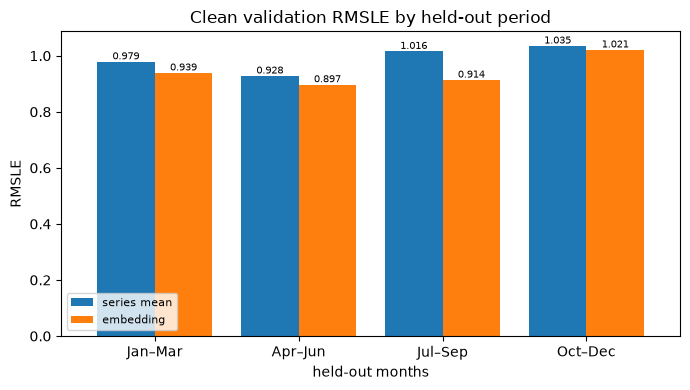

In [5]:
table = results.pivot(index="fold", columns="model", values=["val_clean", "val_all"]).reindex(list(FOLDS))
table.loc["average"] = table.mean()
for score in ["val_clean", "val_all"]:
    table[(score, "mean − emb")] = table[(score, "mean")] - table[(score, "emb")]
display(table[[(s, c) for s in ["val_clean", "val_all"] for c in ["mean", "emb", "mean − emb"]]].round(3))

meter_table = by_meter.pivot_table(index="meter", columns="model", values="val_clean").reindex(list(METERS.values()))
meter_table["mean − emb"] = meter_table["mean"] - meter_table["emb"]
display(meter_table.round(3).rename_axis("clean RMSLE, average over folds"))

ax = table.loc[list(FOLDS), "val_clean"][["mean", "emb"]].plot.bar(figsize=(7, 4), rot=0, width=0.8)
ax.set(title="Clean validation RMSLE by held-out period", xlabel="held-out months", ylabel="RMSLE")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7)
ax.legend(["series mean", "embedding"], fontsize=8)
plt.tight_layout()

## Findings

- **The embedding model is better in every season, so the mean model fails the rule.** Clean RMSLE, fold average:
  0.943 vs 0.990, a gap of 0.047 (almost 5× the margin). Per fold 0.014–0.102; all rows 1.203 vs 1.241.
  mlp_4out_emb stays the submission model.
- **Oct–Dec, the split the project first chose by, has the smallest gap** (0.014). That's why they looked tied there. The
  largest is Jul–Sep (0.102).
- **The gain is in heating and cooling:** chilled water 0.078, steam 0.090, electricity only 0.009. The series mean
  gives one level per series, averaged over the training months. The embedding can also learn how a building reacts
  to the weather, which matters for seasonal meters.
- **The extra parameters aren't memorization.** 31K vs 7K parameters and a lower training error (0.83 vs 0.88), yet
  better validation on every fold.
- **Not noise.** The embedding runs repeat regularization_test.ipynb's "none" setup (same rows, seed, epochs) to within
  0.007 on every fold; every per-fold gap here is larger.
- **season_validation.ipynb's conclusion holds for this model too:** anomalies cost 0.49 / 0.33 / 0.14 / 0.09 by fold,
  vs 0.48 / 0.32 / 0.12 / 0.09 for the mean model.

One seed per run.